# ✨ **Day4 : 解析 AI 代理工作流程**

❤️ | Created by [hengshiousheu](https://huggingface.co/Heng666).

✒️ | Edited by seventeen0106.

# ✒️LangGraph 的核心元件（實戰應用：天氣查詢 Agent）

創建一個天氣助手，它可以為我們提供任何位置的天氣資訊

![img](https://i.imgur.com/KPN6sOH.png)

有條件地運行天氣工具，表示我們只會在使用者詢問天氣資訊時運行該工具，否則我們不會做出任何回應

## 0️⃣ 環境建置

In [1]:
%%capture --no-stderr
%pip install --upgrade --quiet langchain
%pip install --upgrade --quiet langchain-openai
%pip install --upgrade --quiet langgraph
%pip install --upgrade --quiet langchain-community

In [2]:
import os
import getpass
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

### 圖(Graph): LangGraph 的核心結構

LangGraph 的核心是將代理工作流程建模為圖，你可以制定你的 AI 代理行為，使用上面介紹的關鍵元素：

> 喔對了，LangGraph 還有個特別的 `MessageGraph` 類別。這種圖的狀態就只是一串訊息列表。雖然主要用在聊天機器人上，但大多數應用可能需要更複雜的狀態結構。

想要開始打造你的 LangGraph 嗎？來看看這個簡單的範例：

## 1️⃣ 狀態(state)：消息的共享中心

> 狀態是捕獲應用程序當前快照的共享資料結構，使節點能夠相互通信和交換訊息。它可以是任何 Python 類型,但通常是 TypedDict 或 Pydantic BaseModel。

有兩種類型的圖可以在 LangGraph 中創建::

- 基本圖(Basic Graph): 只能將一個節點的輸出傳遞給下一個節點。因為無法包含狀態
- 有狀態圖圖(Stateful Graph): 可以包含在節點之間傳遞的狀態,並且可以在任何節點訪問此狀態。

In [3]:
from typing import TypedDict, Annotated, Sequence
import operator

# ==========================================
# 步驟 1：定義狀態 (State Schema)
# ==========================================
# 定義圖在運行時傳遞的資料結構。
# 使用 Annotated[list, operator.add] 意思是：當有新資料回傳時，是用「附加 (append)」的方式加入列表，而不是覆蓋原本的紀錄。
class AllState(TypedDict):
    messages: Annotated[list, operator.add]

## 2️⃣ 節點(Node)：工作流程的基石

每個節點都是一個工作站，負責接收原材料（輸入），進行加工（處理），然後產出成品（輸出）。

這些「工作站」可以執行各種操作，從簡單的資料轉換到複雜的下達決策。


### 2.1 提取城市名稱

接受用戶輸入並從用戶的查詢中提取城市名稱，並將其傳遞到下一個節點

In [4]:
# 引入 LangChain 中用來串接 OpenAI 格式語言模型的套件
from langchain_openai import ChatOpenAI
# 引入用來建立提示詞範本（Prompt Template）的套件
from langchain_core.prompts import ChatPromptTemplate

# ==========================================
# 步驟 2：設定模型與執行鏈 (準備 AI 大腦)
# ==========================================
## 1. 初始化語言模型 (LLM)
model = ChatOpenAI(
    model="gpt-4.1-nano",
    openai_api_base="https://api.apertis.ai/v1",
)

## 2. 定義提示詞字串範本 (Prompt)
prompt_str = """
You are given one question and you have to extract city name from it
Don't respond anything except the city name and don't reply anything if you can't find city name
Only reply the city name if it exists or reply 'no_response' if there is no city name in question

  Here is the question:
  {user_query}
"""

# 將剛剛定義的字串轉換成 LangChain 的 PromptTemplate 物件
prompt = ChatPromptTemplate.from_template(prompt_str)

## 3. 建立執行鏈 (Chain)
# 使用 LangChain 表達式語言 (LCEL)，將 prompt 與 model 串接起來
# 意思是：資料會先進入 prompt 填寫，然後將填寫完的提示詞送給 model 產生結果
chain = prompt | model

## 4. 執行鏈並輸入資料
# 呼叫 invoke 方法，並將字典傳入，把 "請問高雄天氣如何?" 塞入剛剛的 {user_query} 變數中
result = chain.invoke({"user_query": "請問高雄天氣如何?"})

## 5. 印出結果
# result 是一個 AIMessage 物件，.content 可以取得純文字的回答內容
print(result.content)

高雄


### 2.2 回傳天氣狀況（僅模擬）

模擬函數可以回傳該城市的天氣狀況，實務上可以接提供服務的 API，如 openWeather。

In [5]:
# ==========================================
# 步驟 3：定義工具函式 (模擬外部 API)
# ==========================================
def get_taiwan_weather(city: str) -> str:
    # 簡單的字典，用來模擬資料庫查詢
    weather_data = {
        "台北": "晴天，溫度28°C",
        "台中": "多雲，溫度26°C",
        "高雄": "陰天，溫度30°C"
    }
    # 找不到該城市時回傳 '暫無資料'
    return f"{city}的天氣：{weather_data.get(city, '暫無資料')}"

### 2.3 設定條件篩選後得到的回應節點

設定一個回應節點來處理最後輸出的結果

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

model = ChatOpenAI(
    model="gpt-4.1-nano",
    openai_api_base="https://api.apertis.ai/v1",
)

response_prompt_str = """
  You have given a weather information and you have to respond to user's query based on the information

  Here is the user query:
  ---
  {user_query}
  ---

  Here is the information:
  ---
  {information}
  ---
  """
response_prompt = ChatPromptTemplate.from_template(response_prompt_str)

response_chain = response_prompt | model
res = response_chain.invoke({
    "user_query": "請問杜拜天氣如何?",
    "information": "no_response的天氣：暫無資料"
    })
res.content

'目前暫無杜拜的天氣資料，無法提供相關信息。'

### 2.4 將函數轉成節點

In [7]:
# ==========================================
# 步驟 4：定義 LangGraph 的節點 (Nodes)
# ==========================================

## 節點 A：呼叫 LLM 萃取城市名稱
def call_model(state: AllState):
    # 1. 從 state 拿出目前的訊息列表
    messages = state["messages"]

    # 2. 取出最後一條訊息（也就是使用者剛問的問題），放進變數 {user_query} 讓 chain 執行
    user_input = messages[-1]
    response = chain.invoke({"user_query": user_input})

    # 3. 回傳字典。因為我們用了 operator.add，這個 response 會被加到 messages 列表的最後面
    return {"messages": [response]}

## 節點 B：呼叫天氣工具
def weather_tool(state: AllState):
    # 1. 從 state 拿出目前的訊息列表
    context = state["messages"]

    # 2. 經過節點 A 處理後，最後一筆訊息 (-1) 就是 AI 萃取出來的「城市名稱」(例如：高雄)
    city_name = context[-1].content.strip() # .content 是取出文字內容，.strip() 是為了確保把前後不小心多出的空白去掉

    # 3. 把乾淨的城市名稱丟給天氣工具函式
    data = get_taiwan_weather(city_name)

    # 4. 回傳天氣結果
    return {"messages": [data]}

## 節點 C：條件分類函式
# 這個函式不負責處理資料，只負責「看目前的狀態，然後決定下一步往哪走」
def query_classify(state: AllState):
    # 1. 從狀態 (state) 中拿出整疊訊息紀錄
    messages = state["messages"]

    # 2. 最後一筆資料
    ctx = messages[-1]

    # 3. 根據內容進行路由判斷 (Routing)
    # 如果內容等於 "no_response" (代表找不到城市名稱，不需要查天氣)
    if ctx == "no_response":
        # 回傳 "end" 這個字串。拿著這個字串，去對應你前面寫好的字典 {"end": "responder"}，把流程導向 responder
        return "end"
    else:
        # 如果不是 "no_response" (代表有成功萃取出城市名稱)
        # 回傳 "continue" 字串，把流程導向 weather 節點去查天氣 API
        return "continue"

## 節點 D：負責產生最終人性化回覆 (Responder Node)
def responder(state: AllState):
    # 1. 從當前狀態 (state) 中取出整疊「訊息歷史紀錄」
    messages = state["messages"]

    # 2. 呼叫另一個設定好的執行鏈 (response_chain) 來生成最終回答
    # 這裡預期 response_chain 裡面有一個 Prompt，需要填入兩個變數：
    response = response_chain.invoke({
        # messages[0]: 取出列表的「第一筆」資料，也就是使用者最初提問的問題
        "user_query": messages[0],

        # messages[-1]: 最後一筆資料
        "information": messages[-1]
    })

    # 3. 將 AI 潤飾並生成好的最終回覆包裝成字典回傳。這筆回覆會被加到 messages 列表的最後面。
    return {"messages": [response]}

## 3️⃣ 圖(Graph): LangGraph 的核心結構

LangGraph 的核心是將代理工作流程建模為圖，你可以制定你的 AI 代理行為，使用上面介紹的關鍵元素：

> LangGraph 還有個特別的 `MessageGraph` 類別。這種圖的狀態就只是一串訊息列表。雖然主要用在聊天機器人上，但大多數應用可能需要更複雜的狀態結構。


In [8]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AllState)

## 4️⃣ 邊(Edge)：連接節點的橋樑

> 邊就像是工作流程中的傳送帶或決策點。它們定義了信息如何在節點之間流動，以及在什麼條件下流動。

想像一下一個複雜的物流系統：邊決定了包裹（數據或狀態）應該送到哪個下一站。有時候這是一個簡單的直線運輸，有時候則需要根據包裹的特性做出決策

In [9]:
from langgraph.graph import START
from langgraph.graph import END

# 1. 註冊所有的節點 (Nodes)
# 把我們前面寫好的三個功能都加入到圖中
graph_builder.add_node("agent", call_model)      # 負責分析問題、萃取城市名稱
graph_builder.add_node("weather", weather_tool)  # 負責外部查詢 (假的天氣 API)
graph_builder.add_node("responder", responder)   # 負責將資料融合，寫出通順的最終回答

# 2. 設定起點 (Entry Point)
# 規定每次執行時，第一站一定要先經過 agent 節點
graph_builder.set_entry_point("agent")

# 3. 建立「條件邊」(Conditional Edge) 🌟 這是靈魂所在！
# 當資料離開 'agent' 節點後，會呼叫 `query_classify` 這個判斷函式
graph_builder.add_conditional_edges(
    'agent',          # 出發的節點
    query_classify,   # 負責做決定的函式 (它會去檢查目前的 state，然後回傳特定字串)
    {
        # 這裡是一個字典，負責將 query_classify 的回傳值對應到下一個節點：
        # 如果判斷函式回傳 "end" (代表這題不用查天氣，例如使用者只是說「你好」) -> 直接送到 responder
        "end": "responder",

        # 如果判斷函式回傳 "continue" (代表這題有提到城市，需要查天氣) -> 送到 weather 節點
        "continue": "weather"
    }
)

# 4. 建立「一般邊」(Normal Edges)
# 規定天氣查完之後，下一步一定要交給 responder 來包裝回覆
graph_builder.add_edge("weather", "responder")

# 規定 responder 包裝完回覆後，走到 END，結束這次的對話流程
graph_builder.add_edge("responder", END)

# 5. 編譯 (Compile)
# 將這張設計好的藍圖，編譯成可以實際接收輸入並運作的應用程式
app = graph_builder.compile()

## 5️⃣ 視覺化流程

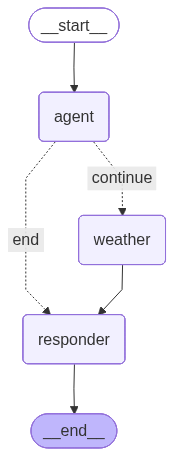

In [10]:
from IPython.display import Image, display

# 使用 try...except 區塊來捕捉可能的錯誤，避免程式因為畫不出圖而整個崩潰
try:
    # 1. app.get_graph(): 從剛剛編譯好的 app 中取得圖的結構
    # 2. draw_mermaid_png(): 將結構轉換成 Mermaid 格式的流程圖，並輸出成 PNG 圖片檔
    # 3. Image() 與 display(): 這是 Jupyter Notebook (或 Colab) 特有的功能，用來在畫面上直接顯示圖片
    display(Image(app.get_graph().draw_mermaid_png()))

except Exception: # 如果發生任何錯誤 (Exception)，就執行這裡
    pass

In [11]:
init_state = {"messages": ["想知道高雄天氣如何？"]}
response = app.invoke(init_state)
response['messages'][-1].content

'高雄今天是陰天，氣溫大約30°C。'

In [12]:
init_state = {"messages": ["想知道杜拜天氣如何？"]}
response = app.invoke(init_state)
response['messages'][-1].content

'您好，目前我們沒有杜拜的天氣資料，建議您稍後再查詢或使用其他天氣資訊來源。'

# ⚠️ 除錯紀錄

最後執行結果印出：

> *'目前僅有「高雄」這個地點資訊，沒有提供高雄的天氣狀況...'*

明明已經有 `weather_tool` 查到天氣了，為什麼最後 AI 卻說沒有天氣資訊？

這份程式碼中藏著 **2 個關於陣列索引（Index）的邏輯陷阱**：

## 🚨 問題一：`responder` 抓錯「天氣資料」了

我們來模擬一下程式執行時，`messages` 這個箱子裡到底裝了什麼：

1. 一開始 (初始狀態)： `messages = ["想知道高雄天氣如何？"]`
2. 經過 `agent` 萃取後： `messages = ["想知道高雄天氣如何？", "高雄"]`
3. 經過 `weather` 查完後： `messages = ["想知道高雄天氣如何？", "高雄", "高雄的天氣：陰天，溫度30°C"]`

```python
response = response_chain.invoke({
    "user_query": messages[0],    # 抓到 "想知道高雄天氣如何？" (正確)
    "information": messages[1]    # 🚨 抓到 "高雄"，而不是天氣資料！
})

```

**✅ 解決方法：**
將 `responder` 中抓取 `information` 的邏輯改為永遠抓取「最後一筆」資料：

```python
def responder(state: AllState):
    messages = state["messages"]
    response = response_chain.invoke({
        "user_query": messages[0],
        # 改成 messages[-1]，確保永遠抓到剛剛 weather_tool 吐出來的天氣結果
        "information": messages[-1]
```

---

## 🚨 潛在問題二：`query_classify` 的條件永遠不會成立

在你的節點 C `query_classify` 中，程式碼是這樣寫的：

```python
def query_classify(state: AllState):
    messages = state["messages"]
    ctx = messages[0] # 🚨 這裡抓到的是使用者的問題："想知道高雄天氣如何？"
```

**✅ 解決方法：**
將 `query_classify` 中抓取檢查目標的邏輯改為最後一筆：

```python
def query_classify(state: AllState):
    messages = state["messages"]
    # 抓取最後一筆 AI 萃取出來的結果，並用 .content 取出純文字
    # (如果前面有防呆處理過，也要記得 .strip() 清除空白)
    ctx = messages[-1].content.strip()
```

---

## 💡 GPT 提醒

LangGraph 中最常遇到的 bug，通常都發生在「狀態（State）」傳遞時，資料放進去的位置跟你預想的不一樣。只要隨時在腦袋裡（或用 `print`）追蹤 `messages` 陣列在每一個節點長什麼樣子，就能輕鬆避開這類問題！